# What changes if the dart is Student-t?

Notebook 21 fitted six candidate throw distributions to seventeen professionals on held-out
competition darts, and the Student-t won by a wide margin on a single extra parameter. That
settled what a dart *is*. This notebook asks what it costs to have been wrong about it: solve
501 with a t instead of a Gaussian, and see which of the project's answers move.

The place to make the change is narrow. Nothing downstream of `darts/transitions.py` knows
what distribution the dart came from -- the MDP solvers, the checkout charts and the match
model all take the same `(n_points, n_scores)` matrix of "aim here, score that with this
probability", and never see $\Sigma$ again. A different throw is a different kernel and
nothing else.

Three things have to be got right before any comparison means anything, and two of them are
easy to get wrong silently. They are the first half of this notebook.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts import players
from darts.dartboards import generate_dartboard
from darts.players import ABILITY_BANDS
from darts.transitions import (aim_points, expected_score_map, gaussian_kernel,
                               matched_scale, scoring_average, student_t_kernel,
                               transition_arrays, _correlate_fft)
from darts.utils import aim_description, region_label

PIXELS = players.BOARD_PIXELS
MM_PER_PX = 2 * 225.5 / PIXELS
BANDS = list(ABILITY_BANDS)
NU = 2.25          # what notebook 21 fitted; 3 and 5 are solved too
BOARD, CHECKOUTS = generate_dartboard(PIXELS)

RES = os.path.join(module_path, 'results')
G = pd.read_csv(os.path.join(RES, 'manifest_single_player.csv'))
T = pd.read_csv(os.path.join(RES, 'manifest_student_t.csv'))
gauss = lambda b: np.load(os.path.join(RES, 'single_player', f'{b}_darts.npz'))
tee = lambda b, nu=NU: np.load(os.path.join(RES, 'student_t', f'{b}_nu{nu:g}_darts.npz'))
print(f'{len(T)} Student-t solves, nu in {[float(x) for x in sorted(T.nu.unique())]}')

42 Student-t solves, nu in [2.25, 3.0, 5.0]


## 1 · A Gaussian lets you be sloppy in two places

The transition builder samples the throw density on the pixel grid and cross-correlates it
with each score's indicator mask. Two shortcuts in that sentence have been free for the whole
project, and neither is free any more.

**Normalising.** `gaussian_kernel` divides the sampled density by its own sum over the window.
That is a *discrete* normalisation over a 512-pixel board, and it is right only because a
Gaussian has essentially nothing outside one. Dividing a heavy tail by its window sum would
take the mass that fell off the board and push it back on, inflating every score.
`student_t_kernel` normalises analytically instead, over the plane, and simply sums to less
than one.

**Wrapping.** The FFT correlation is circular, so mass leaving the left edge of the array
arrives at the right. For a Gaussian that fiction concerns about $10^{-307}$ of the throw. For
a polynomial tail it would score a dart that missed the board wide left as though it had hit
the board on the right.

How much is actually at stake:

In [2]:
scale_px = 9.0                      # a pixel scale in the range these fits produce
Sigma = scale_px ** 2 * np.eye(2)

# gaussian_kernel divides by its own window sum, so it sums to 1 whatever is really
# out there. student_t_kernel at nu=inf is the same density normalised over the plane,
# which is what actually measures the Gaussian's off-board mass.
print(f'mass outside a {PIXELS}-pixel board, kernel scale {scale_px:.0f}px '
      f'({scale_px * MM_PER_PX:.1f}mm):')
def off_board(nu):
    out = 1 - student_t_kernel(PIXELS, Sigma, nu).sum()
    return '< 1e-15 (zero, to floating point)' if abs(out) < 1e-15 else f'{out:.3e}'

print(f'   {"gaussian":>10}  {off_board(np.inf)}')
for nu in (12.0, 5.0, 3.0, 2.25):
    print(f'   {"t, nu=" + format(nu, "g"):>10}  {off_board(nu)}')

# The t nests the Gaussian, so nu -> infinity is a free continuity check on the new code.
for label, S in [('isotropic', Sigma),
                 ('sheared', np.array([[81.0, 24.0], [24.0, 42.0]]))]:
    g = gaussian_kernel(PIXELS, S)
    rel = np.abs(student_t_kernel(PIXELS, S, np.inf) - g).max() / g.max()
    print(f'\nnu = inf reproduces gaussian_kernel ({label}) to {rel:.1e} of the peak')

mass outside a 512-pixel board, kernel scale 9px (7.9mm):
     gaussian  < 1e-15 (zero, to floating point)
     t, nu=12  4.410e-12
      t, nu=5  1.911e-06
      t, nu=3  1.686e-04
   t, nu=2.25  1.063e-03

nu = inf reproduces gaussian_kernel (isotropic) to 0.0e+00 of the peak

nu = inf reproduces gaussian_kernel (sheared) to 2.9e-16 of the peak


aiming at the treble 20, P(score nothing): gaussian 3.49e-17


                                       t, nu=5   1.64e-04


                                       t, nu=3   1.56e-03


                                       t, nu=2.25   4.46e-03

wrap-around error on P(treble 20), over the whole aiming region: at most 6.3e-06


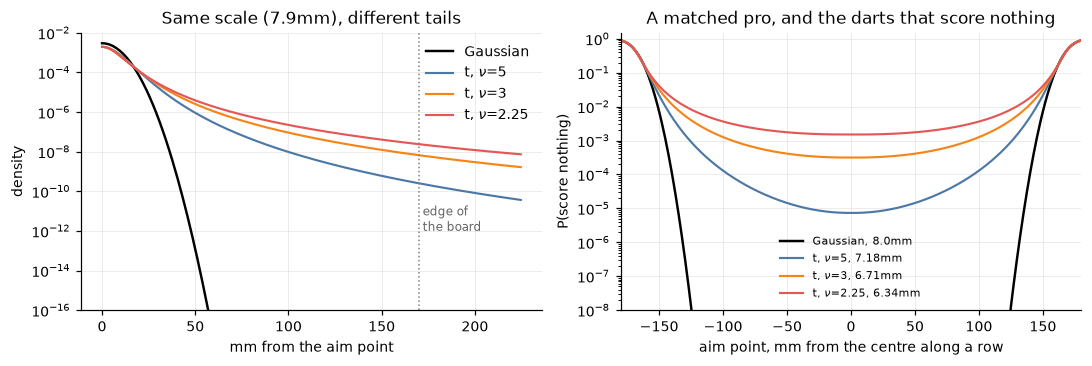

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
c = PIXELS // 2
r_mm = np.arange(0, c) * MM_PER_PX
ax[0].semilogy(r_mm, g[c, c:], 'k-', lw=1.6, label='Gaussian')
for nu, col in zip((5.0, 3.0, 2.25), ('#4c78a8', '#f58518', '#e45756')):
    k = student_t_kernel(PIXELS, Sigma, nu)
    ax[0].semilogy(r_mm, k[c, c:], color=col, lw=1.4, label=f't, $\\nu$={nu:g}')
ax[0].axvline(170, color='0.5', ls=':', lw=1)
ax[0].text(172, 1e-12, 'edge of\nthe board', fontsize=8, color='0.4')
ax[0].set(xlabel='mm from the aim point', ylabel='density', ylim=(1e-16, 1e-2),
          title=f'Same scale ({scale_px * MM_PER_PX:.1f}mm), different tails')
ax[0].legend()

# the mass that has to go somewhere: P(score nothing), aiming out along a row
sig_pro = ABILITY_BANDS['pro']
row = c
xs = (np.arange(PIXELS) - c) * MM_PER_PX
zero_of = lambda tr: tr['board'] == 0
tr_g = transition_arrays(PIXELS, sig_pro, point_stride=1)
iz = list(tr_g['allowed_scores']).index(0)
mask0 = (BOARD == 0).astype(float)[None]
kg = student_t_kernel(PIXELS, sig_pro ** 2 * np.eye(2) / MM_PER_PX ** 2, np.inf)
pg = _correlate_fft(mask0, kg, pad=True)[0]
ax[1].plot(xs, pg[row] + (1 - kg.sum()), 'k-', lw=1.6, label='Gaussian, 8.0mm')
for nu, col in zip((5.0, 3.0, 2.25), ('#4c78a8', '#f58518', '#e45756')):
    sc = matched_scale(sig_pro, nu, board=BOARD)
    kk = student_t_kernel(PIXELS, sc ** 2 * np.eye(2) / MM_PER_PX ** 2, nu)
    pp = _correlate_fft(mask0, kk, pad=True)[0]
    ax[1].plot(xs, pp[row] + (1 - kk.sum()), color=col, lw=1.4,
               label=f't, $\\nu$={nu:g}, {sc:.2f}mm')
ax[1].set(xlabel='aim point, mm from the centre along a row', ylabel='P(score nothing)',
          yscale='log', ylim=(1e-8, 1.5), xlim=(-180, 180),
          title='A matched pro, and the darts that score nothing')
ax[1].legend(fontsize=7.5)
fig.tight_layout()

print(f'aiming at the treble 20, P(score nothing): '
      f'gaussian {tr_g["probs"][:, iz][(tr_g["probs"] @ tr_g["allowed_scores"]).argmax()]:.2e}')
for nu in (5.0, 3.0, 2.25):
    tt = transition_arrays(PIXELS, matched_scale(sig_pro, nu, board=BOARD),
                           point_stride=1, nu=nu)
    print(f'{"":>39}t, nu={nu:g}   '
          f'{tt["probs"][:, iz][(tt["probs"] @ tt["allowed_scores"]).argmax()]:.2e}')

# and what wrapping alone would have done, for the record
m60 = (BOARD == 60).astype(float)[None]
kt = student_t_kernel(PIXELS, Sigma, 2.25)
wrap = (_correlate_fft(m60, kt, pad=False)[0] - _correlate_fft(m60, kt, pad=True)[0])
pts_all = aim_points(PIXELS, 2.0, 2)
print(f'\nwrap-around error on P(treble 20), over the whole aiming region: '
      f'at most {np.abs(wrap[pts_all[:, 0], pts_all[:, 1]]).max():.1e}')

In [4]:
# The off-board rate was never a matching target -- the scale was chosen to reproduce a
# three-dart average and nothing else -- so the real number is an out-of-sample check.
try:
    from darts.real_data import scoring_visits
    V = scoring_visits(clean=True)
    beds = V[[1, 2, 3]].values.ravel()
    print(f'real professional darts, cleaned, {len(beds):,} pure-scoring throws:')
    print(f'   off the board, all three darts   {(beds == "MISS").mean():.5f}')
    for i in (1, 2, 3):
        print(f'   off the board, dart {i}            {(V[i] == "MISS").mean():.5f}')
except Exception as exc:
    print('real data not built (see data/real/README.md):', exc)

real professional darts, cleaned, 73,824 pure-scoring throws:
   off the board, all three darts   0.00322
   off the board, dart 1            0.00012
   off the board, dart 2            0.00354
   off the board, dart 3            0.00601


A Gaussian at a pro's width has nothing outside the board -- not "very little", *nothing*, to
the last bit of a float. That is why dividing by the window sum has always been safe, and it
is why nobody has ever had to think about either shortcut.

A Student-t at $\nu = 2.25$ leaves **one dart in a thousand** out there. Renormalising would
have taken that thousandth and shared it out over the board's scores in proportion to how
often they were already hit -- adding a little to the treble 20 because the treble 20 is
common. It is not a little more treble 20. It is a dart on the floor.

The wrap-around turns out to be the smaller of the two problems: over the whole aiming region
it moves P(treble 20) by at most $6 \times 10^{-6}$. It is fixed anyway, because padding is
what makes the off-board mass identifiable in the first place -- under a circular transform
the mass never leaves, so there is nothing to book.

The right-hand panel is the same fact in the currency that matters. Aiming at the treble 20, a
pro Gaussian scores nothing once in $3 \times 10^{16}$ darts -- which is to say never, in the
history of the sport. The matched t does it once in 224.

And 224 is close to right. Cleaned professional competition darts miss the board on **0.32%**
of pure-scoring throws -- 0.012% on the first dart of a visit and 0.60% on the third, the aim
moving across the visit exactly as notebook 20 found. The matched t predicts **0.45%**. That
was not fitted: the scale was chosen to reproduce a three-dart average and the off-board rate
fell out of it. The Gaussian's answer to the same question is zero, and it is not a close
zero.

And the continuity check passes: at $\nu = \infty$ the t kernel is `gaussian_kernel`, to the
last bit for a spherical throw and to $3 \times 10^{-16}$ of the peak for a sheared one.

## 2 · You cannot compare a t and a Gaussian at the same $\sigma$

A t's scale is not a standard deviation. At $\nu = 2.25$ the variance is
$\nu/(\nu-2) = 9$ times the scale, so handing a t the ability band's $\sigma$ produces a far
worse player and every difference that follows is that, not the distribution. Something has to
be held fixed, and the choice is not free -- the three obvious candidates disagree with each
other materially.

In [5]:
sig = ABILITY_BANDS['pro']
scores = np.unique(BOARD)
i60 = list(scores).index(60)

def one_dart(scale, nu=None):
    tr = transition_arrays(PIXELS, scale, point_stride=1, nu=nu)
    e = tr['probs'] @ tr['allowed_scores']
    return dict(avg=3 * e.max(), p_t20=tr['probs'][:, i60].max())

base = one_dart(sig)
print(f"a pro Gaussian, sigma {sig}mm: three-dart average {base['avg']:.2f}, "
      f"best P(T20) {base['p_t20']:.4f}\n")
print('the same player as a t, nu=2.25, under each matching convention:')
rows = []
per_axis = sig / np.sqrt(NU / (NU - 2))                    # equal per-axis SD
avg_match = matched_scale(sig, NU, board=BOARD)            # equal three-dart average
for name, scale in [('same scale (no matching)', sig),
                    ('per-axis SD', per_axis),
                    ('three-dart average', avg_match)]:
    r = one_dart(scale, nu=NU)
    rows.append(dict(convention=name, scale_mm=round(scale, 2),
                     three_dart_avg=round(r['avg'], 2),
                     avg_vs_gauss=f"{r['avg'] / base['avg'] - 1:+.1%}",
                     p_T20=round(r['p_t20'], 4),
                     T20_vs_gauss=f"{r['p_t20'] / base['p_t20'] - 1:+.1%}"))
print(pd.DataFrame(rows).to_string(index=False))

a pro Gaussian, sigma 8.0mm: three-dart average 101.82, best P(T20) 0.3645

the same player as a t, nu=2.25, under each matching convention:


              convention  scale_mm  three_dart_avg avg_vs_gauss  p_T20 T20_vs_gauss
same scale (no matching)      8.00           89.39       -12.2% 0.3062       -16.0%
             per-axis SD      2.67          147.35       +44.7% 0.7352      +101.7%
      three-dart average      6.34          101.82        +0.0% 0.3898        +6.9%


Three conventions, three completely different players.

**Same scale** hands the t the band's $\sigma$ and gets a **12% worse** scorer. Every
difference measured downstream would have been that, dressed up as a distributional effect.

**Per-axis standard deviation** is the statistician's reflex and it is worse, in the other
direction. Dividing out the ninefold variance inflation leaves a **2.67 mm** core -- a player
who averages 147 and hits the treble 20 **twice as often as a professional**. No such darts
player exists. The arithmetic is right; the quantity is wrong. A t's variance is dominated by
the rare wide darts and says almost nothing about the core that does the scoring, so fixing
the variance fixes the wrong end of the distribution.

**Three-dart average** is what the ability bands already mean -- `players.py` names them for
it, and it is the number a darts player recognises. It puts the pro at 6.34 mm and then leaves
the treble rate free: matched on the average, the t hits **6.9% more trebles**. That number is
a result rather than an assumption, and it is the first sign of everything that follows.

In [6]:
rows = []
for b, s in ABILITY_BANDS.items():
    row = dict(band=b, sigma_mm=s, gauss_avg=round(scoring_average(s, board=BOARD), 2))
    for nu in (2.25, 3.0, 5.0):
        row[f'scale_nu{nu:g}'] = round(matched_scale(s, nu, board=BOARD), 2)
    rows.append(row)
matched = pd.DataFrame(rows)
print('scale in mm that reproduces the band\'s three-dart average:')
print(matched.to_string(index=False))
print('\nfitted cores in notebook 21 ran 5.7-9.0mm across seventeen professionals '
      '(nu 2.05-12);\nthe matched pro core here is '
      f"{matched.loc[matched.band == 'pro', 'scale_nu2.25'].iloc[0]:.2f}mm.")

scale in mm that reproduces the band's three-dart average:
        band  sigma_mm  gauss_avg  scale_nu2.25  scale_nu3  scale_nu5
       elite       6.5     113.88          5.09       5.41       5.82
         pro       8.0     101.82          6.34       6.71       7.18
      county      10.0      88.40          8.15       8.56       9.09
super_league      13.0      72.90         11.09      11.53      12.08
      league      16.0      61.97         14.14      14.60      15.14
        club      20.0      53.31         18.02      18.62      19.27
         pub      28.0      45.10         24.24      25.25      26.44

fitted cores in notebook 21 ran 5.7-9.0mm across seventeen professionals (nu 2.05-12);
the matched pro core here is 6.34mm.


The matched cores land where notebook 21's fits landed. Seventeen professionals fitted cores
between 5.7 and 9.0 mm; matching the pro band's average gives 6.34 mm, the elite band's
5.09 mm, the county band's 8.15 mm. Nothing arranged that -- the matching never saw the real
data and the fits never saw the ability bands -- so the agreement is worth something. The
per-axis convention would have said 2.67 mm, which no fit came close to.

## 3 · The control: at $\nu = \infty$ the whole pipeline must give the Gaussian back

The t path uses a different kernel, a zero-padded transform and an explicit off-board term,
and then hands the result to the same solver. At $\nu = \infty$ all of that has to land on the
Gaussian answer exactly -- not approximately -- or every comparison below is measuring the new
code rather than the new distribution.

In [7]:
from scripts.solve_single_player import OBJECTIVES
from darts.mdp_3turn import ThreeDartMDP

tr = transition_arrays(PIXELS, ABILITY_BANDS['pro'], point_stride=2, nu=np.inf)
ctrl = ThreeDartMDP(tr['probs'], tr['checkout_probs'], tr['allowed_scores'],
                    501, **OBJECTIVES['darts']).solve()
ref = gauss('pro')
print(f"darts to finish 501:  gaussian {-ref['V1'][501]:.6f}   nu=inf {-ctrl.V1[501]:.6f}")
print(f"value, max difference over all 502 scores: {np.abs(ref['V1'] - ctrl.V1).max():.2e}")
print(f"first-dart policy identical at every score: "
      f"{bool((ref['pol1'] == ctrl.pol1).all())}")

darts to finish 501:  gaussian 16.917886   nu=inf 16.917886
value, max difference over all 502 scores: 1.42e-14
first-dart policy identical at every score: True


Identical. The value function agrees across all 502 scores to $10^{-14}$, and the first-dart
policy is the same aim point at every one of them. The new kernel, the padded transform and
the explicit off-board term add up to exactly nothing when the tail is switched off, so
whatever the rest of this notebook shows is the distribution and not the plumbing.

## 4 · The scoring phase does not care

The project's headline scoring result is a threshold: aim at the treble 20 while
$\sigma < 16.8$ mm, and at the treble 19 above it (notebook 03 amended it from the published
17 mm). It is the one number a reader is most likely to have taken away, so it is the one to
check first.

In [8]:
def best_target(scale, nu=None):
    S = float(scale) ** 2 * np.eye(2) / MM_PER_PX ** 2
    e = expected_score_map(BOARD, S, nu=nu)
    return region_label(np.unravel_index(e.argmax(), e.shape), PIXELS)

# bisect for the sigma at which the best single target stops being the T20
def crossover(nu, lo=15.0, hi=19.0, steps=13):
    for _ in range(steps):
        mid = 0.5 * (lo + hi)
        scale = matched_scale(mid, nu, board=BOARD)
        if best_target(scale, nu) == 'T20':
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)

print('sigma at which the best single target switches T20 -> T19:')
print(f'   {"gaussian":>12}  {crossover(None):.2f} mm   (published: 16.8)')
for nu in (5.0, 3.0, 2.25):
    print(f'   {"t, nu=" + format(nu, "g"):>12}  {crossover(nu):.2f} mm')

sigma at which the best single target switches T20 -> T19:


       gaussian  16.80 mm   (published: 16.8)


        t, nu=5  16.52 mm


        t, nu=3  16.67 mm


     t, nu=2.25  16.91 mm


In [9]:
rows = []
for b in BANDS:
    r = dict(band=b)
    for tag, d in (('gauss', gauss(b)), ('t', tee(b))):
        labs = [region_label(d['points'][d['pol1'][s]], PIXELS) for s in range(180, 502)]
        rad = np.array([np.hypot(*(d['points'][d['pol1'][s]] - PIXELS // 2))
                        for s in range(180, 502)]) * MM_PER_PX
        r[f'aim_{tag}'] = max(set(labs), key=labs.count)
        r[f'in_treble_{tag}'] = round(sum(l.startswith('T') for l in labs) / len(labs), 2)
        r[f'radius_{tag}'] = round(rad.mean(), 1)
    rows.append(r)
print('where the first dart of a scoring visit is aimed, over every score from 180 up')
print('(the treble ring runs 99-107mm from the centre):')
print(pd.DataFrame(rows).to_string(index=False))

where the first dart of a scoring visit is aimed, over every score from 180 up
(the treble ring runs 99-107mm from the centre):
        band aim_gauss  in_treble_gauss  radius_gauss aim_t  in_treble_t  radius_t
       elite       T20             0.99         101.5   T20          1.0     102.2
         pro       T20             1.00         102.2   T20          1.0     102.2
      county       T20             1.00         103.9   T20          1.0     103.9
super_league       T20             1.00         104.0   T20          1.0     104.0
      league       T20             1.00         105.7   T20          1.0     103.9
        club        19             0.00         107.0   T19          1.0     104.2
         pub       T19             1.00         105.0   T19          1.0     103.1


The crossover survives. **16.80 mm** under a Gaussian -- reproducing the published number
through an entirely different code path -- and 16.52 to 16.91 mm under a t, depending on
$\nu$. It does not even move in a consistent direction with tail weight. Anyone who took away
"aim at the treble 20 below 16.8 mm, the treble 19 above it" can keep it.

The aim points agree too, to the pixel, for five of the seven bands. Two do not, and both are
weak players moving the same way. The league band's Gaussian aims 1.8 mm further out. The club
band's aims at a different bed entirely: the **single 19** rather than the treble.

The direction is the point. For a wide Gaussian the best target drifts outward, past the
treble ring at 107 mm and into the fat single beyond it, trading a small high-value bed for a
large low-value one. The t does not make that trade -- its core is tight enough to still want
the treble, and the wildness that makes it a weak player is in a tail you cannot aim your way
out of. Section 9 asks what the difference is worth, which turns out to matter more than the
direction.

## 5 · The difference lives below 170

The scoring phase is matched by construction, so if anything moves it has to move in the
checkout phase. Splitting the leg says how much of the difference is where: `darts_from_501`
against `darts_from_170` against `darts_from_40`.

In [10]:
gd = G[G.objective == 'darts'].set_index('band')
td = T[T.objective == 'darts']
rows = []
for _, r in td.iterrows():
    g0 = gd.loc[r.band]
    rows.append(dict(band=r.band, nu=r.nu, sigma_mm=g0.sigma_mm, scale_mm=r.scale_mm,
                     d501=round(r.value_501 - g0.value_501, 3),
                     d170=round(r.darts_from_170 - g0.darts_from_170, 3),
                     d40=round(r.darts_from_40 - g0.darts_from_40, 3),
                     avg=round(r.three_dart_average - g0.three_dart_average, 2)))
delta = pd.DataFrame(rows)
delta['band'] = pd.Categorical(delta.band, BANDS, ordered=True)
delta = delta.sort_values(['nu', 'band'])
print('Student-t minus Gaussian, in darts (negative = the t finishes sooner):')
print(delta.to_string(index=False))

Student-t minus Gaussian, in darts (negative = the t finishes sooner):
        band   nu  sigma_mm  scale_mm   d501   d170    d40   avg
       elite 2.25       6.5    5.0925 -0.114 -0.165 -0.118  0.76
         pro 2.25       8.0    6.3445 -0.106 -0.161 -0.150  0.56
      county 2.25      10.0    8.1529 -0.032 -0.066 -0.124  0.13
super_league 2.25      13.0   11.0909  0.116  0.101 -0.016 -0.30
      league 2.25      16.0   14.1359  0.229  0.222  0.080 -0.41
        club 2.25      20.0   18.0211  0.187  0.168  0.017 -0.23
         pub 2.25      28.0   24.2367 -1.612 -1.610 -1.734  1.16
       elite 3.00       6.5    5.4108 -0.099 -0.131 -0.097  0.66
         pro 3.00       8.0    6.7064 -0.093 -0.128 -0.122  0.49
      county 3.00      10.0    8.5597 -0.027 -0.045 -0.095  0.11
super_league 3.00      13.0   11.5302  0.100  0.093  0.003 -0.25
      league 3.00      16.0   14.6017  0.209  0.204  0.096 -0.38
        club 3.00      20.0   18.6206  0.248  0.239  0.120 -0.30
         pub 3.00  

`d501` and `d170` are the same number to a few hundredths of a dart in every single row. The
entire difference between the two distributions is in the checkout phase. That is what
matching on the scoring average was meant to arrange, and this is the check that it did.

The size, and the *sign*, depend on ability -- and not monotonically:

* **elite and pro** finish about **0.11 darts sooner** as a t (+0.76 and +0.56 on the
  three-dart average)
* **super league, league and club** finish **0.12 to 0.23 darts later** ($-0.2$ to $-0.4$)
* **pub** finishes **1.61 darts sooner** -- 1.16 points of average, by far the largest effect
  in the table

Six of the seven bands move further from the Gaussian as $\nu$ falls, which is the internal
consistency the table should show: heavier tail, bigger effect, same direction. The club band
is the exception, running 0.187, 0.248, 0.251 as $\nu$ goes 2.25, 3, 5 -- the wrong way round
by 0.06 darts. Its aim recommendation is the same T19 at all three $\nu$, so that is not the
cause, and 0.06 darts on a landscape this flat is not worth a theory. It is noted rather than
explained.

## 6 · Why: a t is better at small targets and worse at forgiving ones

Matched on the three-dart average, a t has a *tighter core* than the Gaussian it replaces --
a pro's 6.34mm against 8.0mm -- and pays for it with a few darts that go anywhere at all. That
is not a uniform improvement or a uniform cost. It depends entirely on how big the target is.

Hitting a double is a precision task: the core is everything, and a wild dart was going to
miss regardless. Scoring twenty or more with a dart at the 20 is a forgiving task: the core
was always going to manage it, and a wild dart is a total loss. So the two distributions
should separate in opposite directions on the two, and the leg should follow whichever one it
is mostly made of.

In [11]:
rows = []
for b, s in ABILITY_BANDS.items():
    g_tr = transition_arrays(PIXELS, s, point_stride=2)
    t_tr = transition_arrays(PIXELS, matched_scale(s, NU, board=BOARD),
                             point_stride=2, nu=NU)
    sc = g_tr['allowed_scores']
    i40, i60 = list(sc).index(40), list(sc).index(60)
    r = dict(band=b, sigma_mm=s)
    for tag, tr in (('g', g_tr), ('t', t_tr)):
        r[f'D20_{tag}'] = tr['checkout_probs'][:, i40].max()      # a bed 8mm across
        r[f'T20_{tag}'] = tr['probs'][:, i60].max()               # a bed 8mm across
        r[f'ge20_{tag}'] = tr['probs'][:, sc >= 20].sum(1).max()  # a whole sector
    rows.append(r)
prec = pd.DataFrame(rows)
for k in ('D20', 'T20', 'ge20'):
    prec[f'{k}_ratio'] = (prec[f'{k}_t'] / prec[f'{k}_g']).round(3)
print('best achievable probability with one dart, t relative to the matched Gaussian:')
print(prec[['band', 'sigma_mm', 'D20_g', 'D20_t', 'D20_ratio', 'T20_ratio',
            'ge20_g', 'ge20_t', 'ge20_ratio']].round(4).to_string(index=False))

best achievable probability with one dart, t relative to the matched Gaussian:
        band  sigma_mm  D20_g  D20_t  D20_ratio  T20_ratio  ge20_g  ge20_t  ge20_ratio
       elite       6.5 0.4585 0.4871      1.062      1.043  0.9994  0.9526       0.953
         pro       8.0 0.3798 0.4051      1.067      1.064  0.9944  0.9260       0.931
      county      10.0 0.3059 0.3210      1.049      1.080  0.9707  0.8804       0.907
super_league      13.0 0.2292 0.2334      1.018      1.088  0.8964  0.7966       0.889
      league      16.0 0.1758 0.1761      1.002      1.085  0.7999  0.7080       0.885
        club      20.0 0.1271 0.1287      1.013      1.099  0.6732  0.6047       0.898
         pub      28.0 0.0731 0.0838      1.147      1.237  0.4813  0.4728       0.982


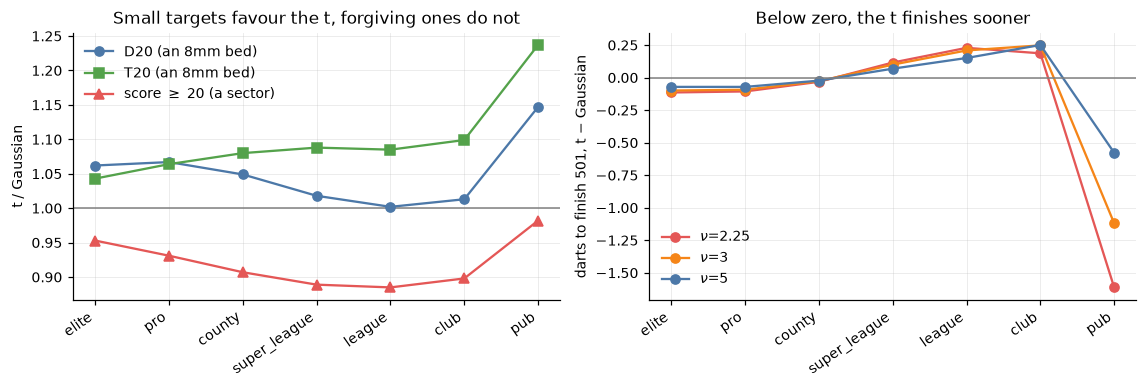

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
x = np.arange(len(BANDS))
ax[0].axhline(1.0, color='0.5', lw=1)
ax[0].plot(x, prec.D20_ratio, 'o-', color='#4c78a8', label='D20 (an 8mm bed)')
ax[0].plot(x, prec.T20_ratio, 's-', color='#54a24b', label='T20 (an 8mm bed)')
ax[0].plot(x, prec.ge20_ratio, '^-', color='#e45756', label='score $\\geq$ 20 (a sector)')
ax[0].set_xticks(x, BANDS, rotation=35, ha='right')
ax[0].set(ylabel='t / Gaussian', title='Small targets favour the t, forgiving ones do not')
ax[0].legend()

for nu, col in zip((2.25, 3.0, 5.0), ('#e45756', '#f58518', '#4c78a8')):
    sub = delta[delta.nu == nu]
    ax[1].plot(x, sub.d501, 'o-', color=col, label=f'$\\nu$={nu:g}')
ax[1].axhline(0.0, color='0.5', lw=1)
ax[1].set_xticks(x, BANDS, rotation=35, ha='right')
ax[1].set(ylabel='darts to finish 501, t $-$ Gaussian',
          title='Below zero, the t finishes sooner')
ax[1].legend()
fig.tight_layout()

Both directions are there, in every band.

On an **8 mm bed** the t is never worse: up to 15% more double 20s, and 4 to 24% more treble
20s. On **"score at least 20 with one dart"** -- which the whole 20 sector satisfies, its
single included -- it is never better: 2 to 12% worse.

That is the whole mechanism. A double is a precision task, where the core is everything and a
wild dart was going to miss anyway; a big number is a forgiving task, where the core was always
going to manage and a wild dart is a total loss. A t trades the second for the first. A leg is
a mixture of the two, and the previous section's sign is just which mixture.

The two extremes make it plain. The **league** band gets *no* precision gain at all
(D20 ratio 1.002) and takes the largest forgiving penalty (0.885) -- and it is the band where
the t loses most, +0.23 darts. The **pub** band gets the largest precision gain (1.147) and
almost no penalty (0.982) -- and it is the band where the t wins most, $-1.61$ darts.

So there is no general answer to whether a heavy tail helps a darts player. It helps the parts
of the game that need a small target hit, hurts the parts that only need a big number, and
legs at different standards are made of those in different proportions.

## 7 · What it does to the checkout chart

The checkout percentages are the project's most directly usable output: given a score, how
often does this player finish it in one visit? They are a checkout-phase quantity, so this is
where the distribution should show up most.

P(finish this visit), Gaussian vs t (nu=2.25):
        band  170_g  170_t  100_g  100_t   60_g   60_t   40_g   40_t   32_g   32_t    2_g    2_t
       elite 0.0764 0.0980 0.4318 0.4616 0.7068 0.7180 0.8411 0.8598 0.8431 0.8613 0.6256 0.6533
         pro 0.0000 0.0502 0.3093 0.3376 0.6140 0.6181 0.7613 0.7804 0.7631 0.7833 0.5429 0.5707
      county 0.0000 0.0205 0.2003 0.2196 0.5104 0.4977 0.6636 0.6737 0.6655 0.6770 0.4451 0.4756
super_league 0.0000 0.0000 0.1007 0.1164 0.3796 0.3534 0.5346 0.5301 0.5369 0.5345 0.3440 0.3647
      league 0.0000 0.0000 0.0559 0.0644 0.2727 0.2502 0.4248 0.4174 0.4300 0.4216 0.2738 0.2809
        club 0.0000 0.0000 0.0276 0.0333 0.1738 0.1635 0.3135 0.3111 0.3198 0.3171 0.2050 0.2106
         pub 0.0000 0.0000 0.0093 0.0134 0.0754 0.0877 0.1765 0.2062 0.1864 0.2094 0.1233 0.1433


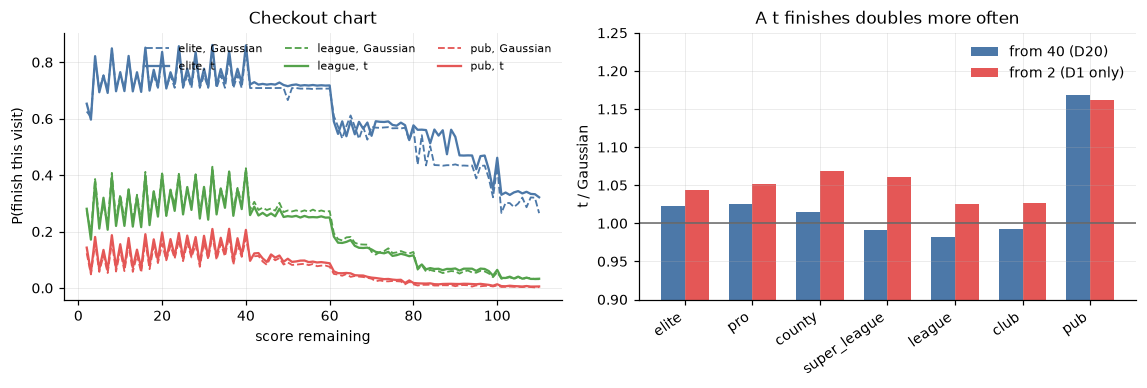

In [13]:
rows = []
for b in BANDS:
    g0, t0 = gauss(b)['checkout_pct'], tee(b)['checkout_pct']
    r = dict(band=b)
    for s in (170, 100, 60, 40, 32, 2):
        r[f'{s}_g'], r[f'{s}_t'] = round(g0[s], 4), round(t0[s], 4)
    rows.append(r)
co = pd.DataFrame(rows)
print('P(finish this visit), Gaussian vs t (nu=2.25):')
print(co.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
for b, col in zip(('elite', 'league', 'pub'), ('#4c78a8', '#54a24b', '#e45756')):
    s = np.arange(2, 111)
    ax[0].plot(s, gauss(b)['checkout_pct'][s], color=col, ls='--', lw=1.2, label=f'{b}, Gaussian')
    ax[0].plot(s, tee(b)['checkout_pct'][s], color=col, lw=1.5, label=f'{b}, t')
ax[0].set(xlabel='score remaining', ylabel='P(finish this visit)', title='Checkout chart')
ax[0].legend(fontsize=7.5, ncol=3)

x = np.arange(len(BANDS))
w = 0.35
ax[1].bar(x - w / 2, [co.loc[co.band == b, '40_t'].iloc[0] / co.loc[co.band == b, '40_g'].iloc[0]
                      for b in BANDS], w, color='#4c78a8', label='from 40 (D20)')
ax[1].bar(x + w / 2, [co.loc[co.band == b, '2_t'].iloc[0] / co.loc[co.band == b, '2_g'].iloc[0]
                      for b in BANDS], w, color='#e45756', label='from 2 (D1 only)')
ax[1].axhline(1.0, color='0.4', lw=1)
ax[1].set_xticks(x, BANDS, rotation=35, ha='right')
ax[1].set(ylabel='t / Gaussian', ylim=(0.9, 1.25), title='A t finishes doubles more often')
ax[1].legend()
fig.tight_layout()

The chart moves the way section 6 says it must. From **2** -- a double 1 and nothing else, the
purest precision task on the board -- the t finishes more often for **all seven bands**, by 3
to 16%. From **40** it is better for elite, pro, county and pub, and marginally worse for the
middle three, which is the same sign pattern as the leg value.

The differences are not decorative. An elite player's chance of finishing 40 goes from 84.1%
to 86.0%, and a pub player's from 17.7% to 20.6%. Those are the numbers a checkout chart is
consulted for.

## 8 · Fifty left, one dart: do you go for it?

The top of that chart hides the sharpest consequence in the notebook. Two of the seven bands
finish 170 in a visit essentially never under a Gaussian and a few per cent of the time under
a t -- and a probability does not move from zero to five per cent because a tail got fatter.
It moves because the solver changed its mind about what to attempt.

In [14]:
print('a visit that started on 170, first dart:')
for b in ('elite', 'pro', 'county', 'super_league'):
    g0, t0 = gauss(b), tee(b)
    print(f'   {b:>13}  gaussian {aim_description(g0["points"][g0["pol1"][170]], PIXELS):>5}'
          f'  P(finish) {g0["checkout_pct"][170]:.4f}   |   '
          f't {aim_description(t0["points"][t0["pol1"][170]], PIXELS):>5}'
          f'  P(finish) {t0["checkout_pct"][170]:.4f}')

print('\nT20, T20 leaves 50 with one dart to throw. What does that dart aim at?')
for b in ('elite', 'pro', 'county', 'super_league', 'league'):
    g0, t0 = gauss(b), tee(b)
    print(f'   {b:>13}  gaussian {aim_description(g0["points"][g0["pol3low"][170, 50]], PIXELS):>6}'
          f'   |   t {aim_description(t0["points"][t0["pol3low"][170, 50]], PIXELS):>6}')

a visit that started on 170, first dart:
           elite  gaussian   T20  P(finish) 0.0764   |   t   T20  P(finish) 0.0980
             pro  gaussian   T19  P(finish) 0.0000   |   t   T20  P(finish) 0.0502
          county  gaussian   T20  P(finish) 0.0000   |   t   T20  P(finish) 0.0205
    super_league  gaussian   T20  P(finish) 0.0000   |   t   T20  P(finish) 0.0000

T20, T20 leaves 50 with one dart to throw. What does that dart aim at?
           elite  gaussian   BULL   |   t   BULL
             pro  gaussian     18   |   t   BULL
          county  gaussian     18   |   t   BULL
    super_league  gaussian     18   |   t     18
          league  gaussian     18   |   t     18


There it is. Facing 50 with one dart left, having started the visit on 170:

**a Gaussian pro throws at the single 18, to leave 32 for the next visit. A Student-t pro of
the same three-dart average throws at the bull and tries to win the leg.**

The county band flips the same way. The elite band throws at the bull under both -- it is good
enough that the Gaussian already likes the odds -- and super league and league throw at the 18
under both, being too wide for either. So the flip is where you would expect it: at the two
bands sitting on the fence. It is the clearest
statement of what the distribution is worth: not a small correction to a probability, but a
different decision at the table. And it goes the direction that flatters the t -- more darts at
the bull, more 170 finishes attempted -- because the matched t is the better shot at a small
target, which is what the bull is.

The pro's first dart at 170 moves for the same reason: under a Gaussian it is the treble 19,
setting up rather than attempting, and P(finish this visit) is 0.0000 because the model never
tries. Under a t it is the treble 20, the first dart of a real 170 attempt, and the visit
finishes 5.0% of the time.

## 9 · One recommendation flips, and its margin says how much to make of it

Five of the seven bands aim at exactly the same place under both distributions. One does not.
Notebook 03 met this situation before and left the right warning attached to it: when two
aiming points are worth nearly the same, the argmax flips for reasons worth nothing. So the
flip is only interesting alongside what it is worth.

In [15]:
for b in ('club', 'pub'):
    g0, t0 = gauss(b), tee(b)
    print(f'{b} (sigma {ABILITY_BANDS[b]}mm, matched t scale '
          f'{float(t0["scale_mm"]):.2f}mm), first dart of a visit at 501:')
    for tag, own, other in (('gaussian', g0, t0), ('t, nu=2.25', t0, g0)):
        pts, es = own['points'], own['expected_score']
        i = own['pol1'][501]
        k = int(np.argmin(np.linalg.norm(pts - other['points'][other['pol1'][501]], axis=1)))
        apart = np.linalg.norm(pts[i] - pts[k]) * MM_PER_PX
        print(f'   {tag:>11} prefers {aim_description(pts[i], PIXELS):>4}  '
              f'(E[score] {es[i]:5.2f});  the other model\'s point, '
              f'{aim_description(pts[k], PIXELS):>4} {apart:4.1f}mm away, '
              f'is worth {es[k]:5.2f}  -> margin {es[i] - es[k]:+.3f}')
    print()

club (sigma 20.0mm, matched t scale 18.02mm), first dart of a visit at 501:
      gaussian prefers   19  (E[score] 17.77);  the other model's point,  T19  3.9mm away, is worth 17.68  -> margin +0.088
    t, nu=2.25 prefers  T19  (E[score] 17.76);  the other model's point,   19  3.9mm away, is worth 17.63  -> margin +0.127

pub (sigma 28.0mm, matched t scale 24.24mm), first dart of a visit at 501:
      gaussian prefers  T19  (E[score] 15.03);  the other model's point,  T19  5.3mm away, is worth 14.95  -> margin +0.080
    t, nu=2.25 prefers  T19  (E[score] 15.03);  the other model's point,  T19  5.3mm away, is worth 14.91  -> margin +0.128



The club band's Gaussian prefers the single 19 by **0.088** points of expected score over a
point 3.9 mm away inside the treble. The t prefers that treble point by **0.127**. Both
margins are around a tenth of a point on a dart worth about eighteen.

Notebook 03 met exactly this and drew the right conclusion: where two aiming points are worth
nearly the same, the argmax flips for reasons worth nothing, and a recommendation quoted
without its margin is not a recommendation. The pub row shows the same thing from the other
side -- both models say "T19", and the two points they mean are 5.3 mm apart.

So the honest statement is not that the Gaussian gives weak players the wrong advice. It is
that the treble and the fat single beside it are worth almost the same to a club player under
either distribution, that the tie breaks differently under the two, and that choosing wrongly
costs about a tenth of a point a dart -- roughly 0.02 on a three-dart average. The distribution
decides it. It does not decide much.

## Conclusion

**The change is one kernel.** Nothing below `transitions.py` knew what a Gaussian was, so
nothing below it had to change: `student_t_kernel`, a zero-padded correlation, and the
off-board mass booked as a miss instead of renormalised away. `nu=None` is the Gaussian and
every existing result is bit-for-bit what it was. At $\nu = \infty$ the new path reproduces the
old solve to $10^{-14}$, which is the check that says the rest of this is the distribution.

**Two things had to be got right first, and both are silent when wrong.** Normalising a heavy
tail over the window rather than the plane pushes the darts that missed the board back onto it.
Comparing a t to a Gaussian at equal $\sigma$, or at equal per-axis SD, compares two different
players -- the second convention produces a "pro" who averages 147. Matching on the three-dart
average is the one the ability bands already mean, and it independently lands on the cores
notebook 21 fitted to real professionals.

**The scoring phase is untouched.** The treble 20 / treble 19 crossover moves from 16.80 mm to
between 16.52 and 16.91 mm, not even monotonically in $\nu$. Five of seven bands aim at exactly
the same pixel. The project's most-quoted answer does not depend on the assumption that failed.

**The checkout phase is where it lives, and the sign depends on who is throwing.** Matched on
scoring, an elite or pro t finishes 0.11 darts sooner, the middle bands 0.12 to 0.23 darts
later, and a pub player 1.61 darts sooner. The mechanism is measurable rather than
conjectural: a matched t is 2-15% better at an 8 mm bed and 2-12% worse at a whole sector, and
each band's leg is a different mixture of the two.

**The most concrete consequence is a decision, not a number.** With 50 left and one dart, a
Gaussian pro sets up for 32; a t pro throws at the bull. Facing 170, a Gaussian pro never
attempts the finish and a t pro does, 5% successfully.

**What this does not settle.** These are simulated bands, matched to be equally good scorers,
not fitted players -- the honest reading is "two players who score the same finish
differently", and it is notebook 21's fits, not this notebook, that say real darts are the t.
Turning that into per-player numbers needs the fitting side of the project to speak t as well:
`fitting.py`'s EM has a Gaussian M-step, `design.py` builds the score function of a Gaussian
likelihood, and until those are done a real player's $\nu$ and core cannot be estimated from
their scoresheet. That is the next piece of work, and the roadmap now says so.